# Implementing and Evaluating Softmax Regression for Handwritten Digit Recognition

## Project Overview
This project implements Softmax regression from scratch using NumPy
to classify handwritten digits from 0 to 9 using the MNIST dataset.

The study focuses on the learning framework, cross-entropy loss,
gradient-based optimisation, and generalisation.

## Research Questions
1. How does the learning rate affect training?
2. How does the amount of training data affect generalisation?
3. Why do cross-entropy loss and classification accuracy behave differently?

## 1. Running this notebook

Google Colab is the recommended environment for running the
complete notebook, including both interactive demonstrations.

The core experiments use NumPy and Matplotlib. The dataset
browser additionally uses ipywidgets, and the handwriting canvas
uses Pillow and Google Colab's JavaScript-to-Python callback
interface. Internet access is required to download MNIST.

Run the cells from top to bottom. The notebook downloads the
dataset, trains the models, selects the final model using
validation loss, and evaluates it on the held-out test set.
The demonstrations then load the final model saved by this run.

### Output storage

With `USE_GOOGLE_DRIVE = False`, generated files are saved to
the runtime's `A2_outputs` folder without Drive authentication.
These files are temporary and may be lost when the runtime
is deleted.

With `USE_GOOGLE_DRIVE = True`, generated files are saved to
the configured Google Drive folder after account authorisation.

Choose this setting before running the experiments. If it is
changed later, rerun the affected saving and model-loading cells
so that the demonstrations use the intended files.

Saving the notebook does not automatically back up files created
in the runtime. Saved notebook outputs also do not restore
Python variables or active interactive controls.

### Interactive demonstrations

Run the demonstration preparation cell before running the
dataset browser or handwriting canvas. An active Colab runtime
is required for the controls to work.

After a runtime reset, rerun the notebook in order to restore
its variables, functions and interfaces.

In [ ]:
from pathlib import Path

# Default: anyone can run the notebook without Drive access.
# Set True when saving results to your own Google Drive.
USE_GOOGLE_DRIVE = False

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    output_dir = Path(
        "/content/drive/MyDrive/"
        "32513_Advanced_Data_Analytics_Algorithms/A2_outputs"
    )
else:
    output_dir = Path("A2_outputs")

output_dir.mkdir(parents=True, exist_ok=True)

figure_dir = output_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", output_dir.resolve())

Output folder: /content/A2_outputs


### Experiment settings and rerunning

The following cell centralises the experiment settings. Defaults preserve the recorded experiment. After changing settings, rerun the notebook from the top. Plot titles and saved settings use these values; the written numerical observations describe the original recorded run and must be checked against new outputs.


In [ ]:
import csv
import json
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# Change experiment settings here, then rerun the notebook from the top.
SEED = 42
EPOCHS = 10
BATCH_SIZE = 128
BASELINE_LR = 0.1
LEARNING_RATES = (0.01, BASELINE_LR, 1.0)
VALIDATION_SIZE = 10000
TRAINING_SUBSET_SIZES = (1000, 10000)  # Full training split is added automatically.
CONFIDENCE_THRESHOLD = 0.90

if not isinstance(SEED, int) or SEED < 0:
    raise ValueError("SEED must be a nonnegative integer.")
for name, value in [
    ("EPOCHS", EPOCHS), ("BATCH_SIZE", BATCH_SIZE),
    ("VALIDATION_SIZE", VALIDATION_SIZE)
]:
    if not isinstance(value, int) or value <= 0:
        raise ValueError(f"{name} must be a positive integer.")
if not np.isfinite(BASELINE_LR) or BASELINE_LR <= 0:
    raise ValueError("BASELINE_LR must be finite and positive.")
if (
    not LEARNING_RATES
    or any(not np.isfinite(lr) or lr <= 0 for lr in LEARNING_RATES)
    or len(set(LEARNING_RATES)) != len(LEARNING_RATES)
    or BASELINE_LR not in LEARNING_RATES
):
    raise ValueError("LEARNING_RATES must be unique positive rates including BASELINE_LR.")
if (
    not TRAINING_SUBSET_SIZES
    or any(not isinstance(n, int) or n <= 0 for n in TRAINING_SUBSET_SIZES)
    or len(set(TRAINING_SUBSET_SIZES)) != len(TRAINING_SUBSET_SIZES)
):
    raise ValueError("TRAINING_SUBSET_SIZES must contain unique positive integers.")
if not np.isfinite(CONFIDENCE_THRESHOLD) or not 0 < CONFIDENCE_THRESHOLD < 1:
    raise ValueError("CONFIDENCE_THRESHOLD must be between 0 and 1.")

def total_parameter_updates(n_samples):
    return EPOCHS * ((n_samples + BATCH_SIZE - 1) // BATCH_SIZE)

print("NumPy version:", np.__version__)
print("Environment ready.")


NumPy version: 2.1.3
Environment ready.


## 2. Task definition and dataset
This is an **Option 1 model implementation and study**, using MNIST as a controlled classification example. The task is to predict one of ten handwritten digits, 0–9. Learning from labelled examples avoids having to specify a separate handwritten rule for every writing style.

**Training input:** labelled 28 × 28 grayscale images, with integer labels from 0 to 9. **Training output:** learned weights and biases. **Inference input:** an image in the same format after preprocessing. **Inference output:** ten class probabilities and the digit with the highest probability. Labels are needed for evaluation, but not for inference.

MNIST provides 60,000 original training examples and 10,000 test examples. The notebook downloads a NumPy archive hosted for Keras. It uses NumPy to implement the classifier; it does not use a Keras training API. The scope is MNIST-format images, not arbitrary phone photographs or complete handwritten documents.

In [ ]:
# Download the dataset if it is not already available.
data_path = Path("mnist.npz")
data_url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"

if not data_path.exists():
    urlretrieve(data_url, data_path)

# Load the original training and test sets.
with np.load(data_path, allow_pickle=False) as data:
    X_train_full = data["x_train"]
    y_train_full = data["y_train"]
    X_test_raw = data["x_test"]
    y_test = data["y_test"]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test_raw.shape)
print("Test labels:", y_test.shape)

# Validate both original datasets before splitting or preprocessing.
for name, images, labels in [
    ("Training", X_train_full, y_train_full),
    ("Test", X_test_raw, y_test)
]:
    if images.ndim != 3 or images.shape[1:] != (28, 28):
        raise ValueError(f"{name} images must have shape (N, 28, 28).")
    if labels.ndim != 1 or len(images) != len(labels) or len(labels) == 0:
        raise ValueError(f"{name} images and labels must have matching nonzero lengths.")
    if not np.issubdtype(labels.dtype, np.integer) or np.any((labels < 0) | (labels > 9)):
        raise ValueError(f"{name} labels must be integers from 0 to 9.")
    if not np.isfinite(images).all() or images.min() < 0 or images.max() > 255:
        raise ValueError(f"{name} pixel values must be finite and within [0, 255].")
print("Dataset checks passed.")


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Dataset checks passed.


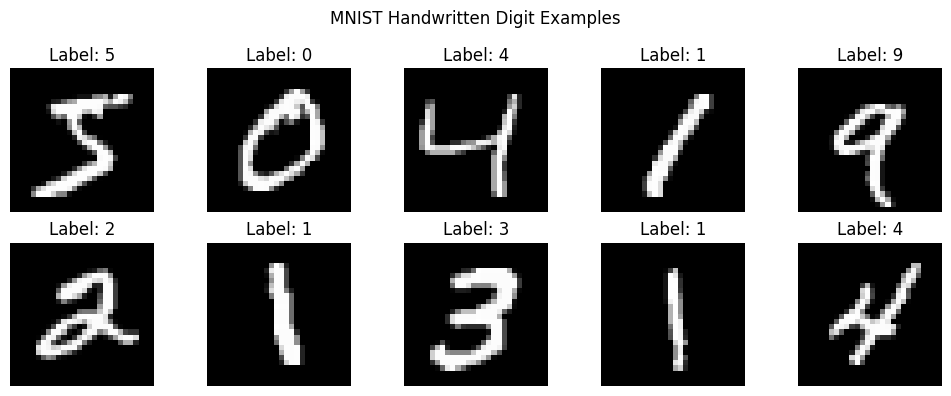

In [ ]:
# Display the first 10 training images and their true labels.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Label: {y_train_full[i]}")
    ax.axis("off")

plt.suptitle("MNIST Handwritten Digit Examples")
plt.tight_layout()
plt.show()
plt.close(fig)

### 2.1 Data split and preprocessing
A fixed random permutation (seed 42) splits the original training data into 50,000 training images and 10,000 validation images. The official 10,000-image test set remains separate. The same indices select images and labels, preserving their correspondence.

Each image is flattened into 784 features and converted to `float32`. Division by the fixed constant 255 scales pixels to [0, 1]; no validation or test statistics are fitted. Flattening preserves the pixel values and their ordering, but this model does not explicitly exploit two-dimensional local structure. Validation results guide model selection; the test set is used only after selection.

In [ ]:
if not 0 < VALIDATION_SIZE < len(y_train_full):
    raise ValueError("VALIDATION_SIZE must leave a non-empty training split.")

# Reset the random generator so rerunning this cell gives the same split.
split_rng = np.random.default_rng(SEED)

# Shuffle the indices of the original 60,000 training examples.
indices = split_rng.permutation(len(X_train_full))

val_indices = indices[:VALIDATION_SIZE]
train_indices = indices[VALIDATION_SIZE:]

# Use matching indices for images and labels.
X_train_raw = X_train_full[train_indices]
y_train = y_train_full[train_indices]

X_val_raw = X_train_full[val_indices]
y_val = y_train_full[val_indices]

print("Training set:", X_train_raw.shape, y_train.shape)
print("Validation set:", X_val_raw.shape, y_val.shape)
print("Test set:", X_test_raw.shape, y_test.shape)

if np.intersect1d(train_indices, val_indices).size:
    raise ValueError("Training and validation indices overlap.")
if len(train_indices) + len(val_indices) != len(y_train_full):
    raise ValueError("The split does not cover the original training set.")
if any(n >= len(y_train) for n in TRAINING_SUBSET_SIZES):
    raise ValueError("Each configured subset must be smaller than the full training split.")
print("Data split checks passed.")


Training set: (50000, 28, 28) (50000,)
Validation set: (10000, 28, 28) (10000,)
Test set: (10000, 28, 28) (10000,)
Data split checks passed.


In [ ]:
def preprocess_images(images):
    # Convert each 28 × 28 image into a vector of 784 pixel values.
    flattened = images.reshape(len(images), -1)

    # Convert to floating point and scale pixels from [0, 255] to [0, 1].
    return flattened.astype(np.float32) / 255.0


X_train = preprocess_images(X_train_raw)
X_val = preprocess_images(X_val_raw)

# Prepare the test inputs, but do not evaluate models on them yet.
X_test = preprocess_images(X_test_raw)

print("Training inputs:", X_train.shape)
print("Validation inputs:", X_val.shape)
print("Test inputs:", X_test.shape)
print("Training pixel range:", X_train.min(), "to", X_train.max())
print("Data type:", X_train.dtype)

Training inputs: (50000, 784)
Validation inputs: (10000, 784)
Test inputs: (10000, 784)
Training pixel range: 0.0 to 1.0
Data type: float32


## 3. Model and learning framework
The hypothesis space is the family of Softmax regression functions parameterised by $W\in\mathbb{R}^{784\times10}$ and $b\in\mathbb{R}^{10}$. There are 7,850 stored parameters. For a batch $X\in\mathbb{R}^{N\times784}$:

$$Z=XW+b,\qquad P_{ik}=\frac{\exp(Z_{ik})}{\sum_{j=0}^{9}\exp(Z_{ij})}.$$

The prediction is $\arg\max_k P_{ik}$. Softmax is nonlinear, but the class scores are affine in the pixels and the pairwise decision boundaries are linear. This makes the model interpretable and computationally modest, while limiting the patterns it can represent.

| Course component | Implementation |
|---|---|
| Data | Preprocessed MNIST images and labels |
| Hypothesis space | `predict_proba`, with parameters `W` and `b` |
| Objective | Mean cross-entropy in `cross_entropy_loss` |
| Optimisation | `compute_gradients` and mini-batch updates in `train_softmax` |

Subtracting each row's maximum score before exponentiation leaves the Softmax probabilities unchanged mathematically and reduces overflow risk. The probability checks below test basic output properties; they do not establish classification performance.

In [ ]:
def softmax(logits):
    # Subtract each row's maximum to avoid exponential overflow.
    shifted = logits - np.max(logits, axis=1, keepdims=True)

    exp_scores = np.exp(shifted)

    # Each row contains the probabilities for one image.
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def predict_proba(X, W, b):
    logits = X @ W + b
    return softmax(logits)


def predict(X, W, b):
    probabilities = predict_proba(X, W, b)
    return np.argmax(probabilities, axis=1)


# Initialise model parameters.
init_rng = np.random.default_rng(SEED)

W = init_rng.normal(
    loc=0.0,
    scale=0.01,
    size=(X_train.shape[1], 10)
).astype(np.float32)

b = np.zeros(10, dtype=np.float32)

print("Weight shape:", W.shape)
print("Bias shape:", b.shape)
print("Total parameters:", W.size + b.size)

Weight shape: (784, 10)
Bias shape: (10,)
Total parameters: 7850


In [ ]:
# Use three training images to inspect the forward calculation.
sample_probs = predict_proba(X_train[:3], W, b)
sample_predictions = predict(X_train[:3], W, b)

print("Probability shape:", sample_probs.shape)
print("\nProbabilities for the first image:")
print(np.round(sample_probs[0], 4))

print("\nProbability sums:")
print(sample_probs.sum(axis=1))

print("\nPredicted labels:", sample_predictions)
print("True labels:     ", y_train[:3])

# Check that the outputs are valid probability distributions.
assert np.all(np.isfinite(sample_probs))
assert np.all(sample_probs >= 0)
assert np.allclose(sample_probs.sum(axis=1), 1.0)

print("\nProbability checks passed.")

Probability shape: (3, 10)

Probabilities for the first image:
[0.0984 0.104  0.103  0.1178 0.0976 0.0902 0.0899 0.0945 0.1058 0.0989]

Probability sums:
[0.99999994 1.         1.        ]

Predicted labels: [3 3 1]
True labels:      [7 7 8]

Probability checks passed.


## 4. Training objective and evaluation metric
For integer labels $y_i$, the mean cross-entropy is

$$L=-\frac{1}{N}\sum_{i=1}^{N}\log P_{i,y_i}.$$

`cross_entropy_loss` computes log probabilities directly from shifted scores for numerical stability. With one-hot targets, this cross-entropy also equals the target-to-prediction KL divergence because the target entropy is zero.

Accuracy measures the proportion of correct final decisions. It discards changes in probability that leave the predicted class unchanged. Cross-entropy responds to those changes and provides gradients; argmax-based accuracy is piecewise constant in the parameters and unsuitable as a direct gradient-descent objective.

For example, increasing the correct-class probability from 0.6 to 0.9 can preserve a correct prediction while reducing loss from about 0.511 to 0.105. Conversely, a lower average loss does not guarantee higher accuracy. Both metrics are therefore monitored.

For ten equal class probabilities, the expected loss is $\log(10)\approx2.302585$. The following check verifies this known case.

In [ ]:
def cross_entropy_loss(logits, y):
    # Shift scores for numerical stability.
    shifted = logits - np.max(logits, axis=1, keepdims=True)

    # Compute log probabilities directly.
    log_sum_exp = np.log(
        np.sum(np.exp(shifted), axis=1, keepdims=True)
    )
    log_probs = shifted - log_sum_exp

    # Select the log probability of the true class for each image.
    n = len(y)
    return -np.mean(log_probs[np.arange(n), y])


def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


# Inspect the same three training images.
sample_logits = X_train[:3] @ W + b

sample_loss = cross_entropy_loss(sample_logits, y_train[:3])
sample_accuracy = accuracy_score(
    y_train[:3],
    predict(X_train[:3], W, b)
)

print(f"Sample cross-entropy loss: {sample_loss:.4f}")
print(f"Sample accuracy: {sample_accuracy:.2%}")

Sample cross-entropy loss: 2.2956
Sample accuracy: 0.00%


In [ ]:
# Equal scores produce a uniform probability distribution.
uniform_logits = np.zeros((3, 10), dtype=np.float64)

uniform_loss = cross_entropy_loss(
    uniform_logits,
    y_train[:3]
)
expected_loss = np.log(10)

print(f"Uniform prediction loss: {uniform_loss:.6f}")
print(f"Expected loss:           {expected_loss:.6f}")

assert np.isclose(uniform_loss, expected_loss)

print("Cross-entropy check passed.")

Uniform prediction loss: 2.302585
Expected loss:           2.302585
Cross-entropy check passed.


## 5. Gradients and optimisation checks
Let $Y$ be the one-hot label matrix. Differentiating the mean cross-entropy through Softmax gives:

$$dZ=(P-Y)/N,\qquad dW=X^\top dZ,\qquad db=\sum_i dZ_i.$$

The code subtracts one at each correct-class position instead of allocating a one-hot matrix. Parameters are updated by $W\leftarrow W-\eta dW$ and $b\leftarrow b-\eta db$. Dividing by the actual batch size also handles the smaller final batch correctly.

The one-step check evaluates the same 128 training examples before and after an update with learning rate 0.1. The recorded loss decreases from 2.303349 to 2.119972. This is a useful sanity check, but is not by itself proof of gradient correctness or generalisation.

In [ ]:
def compute_gradients(X, y, W, b):
    n = len(y)

    # Forward pass: compute class probabilities.
    probabilities = predict_proba(X, W, b)

    # Equivalent to probabilities minus one-hot labels.
    dZ = probabilities.copy()
    dZ[np.arange(n), y] -= 1.0

    # Average over the batch.
    dZ /= n

    # Gradients of weights and biases.
    dW = X.T @ dZ
    db = np.sum(dZ, axis=0)

    return dW, db

In [ ]:
# Use a small batch for a one-step learning check.
X_batch = X_train[:BATCH_SIZE]
y_batch = y_train[:BATCH_SIZE]

learning_rate = BASELINE_LR

# Loss before the update.
loss_before = cross_entropy_loss(
    X_batch @ W + b,
    y_batch
)

# Compute gradients.
dW, db = compute_gradients(X_batch, y_batch, W, b)

# Create updated parameters without changing the original W and b.
W_trial = W - learning_rate * dW
b_trial = b - learning_rate * db

# Evaluate on the same batch after the update.
loss_after = cross_entropy_loss(
    X_batch @ W_trial + b_trial,
    y_batch
)

print("Weight gradient shape:", dW.shape)
print("Bias gradient shape:", db.shape)
print(f"Loss before update: {loss_before:.6f}")
print(f"Loss after update:  {loss_after:.6f}")
print(f"Loss reduction:     {loss_before - loss_after:.6f}")

Weight gradient shape: (784, 10)
Bias gradient shape: (10,)
Loss before update: 2.303349
Loss after update:  2.119972
Loss reduction:     0.183377


### 5.1 Finite-difference gradient check
A small synthetic example checks every weight and bias against central finite differences:

$$\frac{\partial L}{\partial\theta}\approx\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon},\qquad\epsilon=10^{-5}.$$

The check uses float64 for numerical precision and separate variables, so it does not alter the MNIST model. The recorded maximum absolute differences are approximately $1.97\times10^{-11}$ for weights and $1.99\times10^{-11}$ for biases. This supports consistency between the implemented loss and gradients on the checked example, not a proof for every possible input.

In [ ]:
# Verify gradients using a small synthetic example.
check_rng = np.random.default_rng(SEED)

# Float64 improves precision for finite-difference calculations.
X_check = check_rng.normal(size=(5, 4))
y_check = np.array([0, 1, 2, 1, 0])

W_check = check_rng.normal(scale=0.1, size=(4, 3))
b_check = check_rng.normal(scale=0.1, size=3)

# Analytical gradients from our implementation.
dW_check, db_check = compute_gradients(
    X_check, y_check, W_check, b_check
)

epsilon = 1e-5


def numerical_gradient(parameter):
    gradient = np.zeros_like(parameter)

    for index in np.ndindex(parameter.shape):
        original_value = parameter[index]

        parameter[index] = original_value + epsilon
        loss_plus = cross_entropy_loss(
            X_check @ W_check + b_check, y_check
        )

        parameter[index] = original_value - epsilon
        loss_minus = cross_entropy_loss(
            X_check @ W_check + b_check, y_check
        )

        # Restore the parameter after checking it.
        parameter[index] = original_value

        gradient[index] = (
            loss_plus - loss_minus
        ) / (2 * epsilon)

    return gradient


numerical_dW = numerical_gradient(W_check)
numerical_db = numerical_gradient(b_check)

print(
    "Maximum weight gradient difference:",
    np.max(np.abs(dW_check - numerical_dW))
)
print(
    "Maximum bias gradient difference:",
    np.max(np.abs(db_check - numerical_db))
)

assert np.allclose(
    dW_check, numerical_dW, atol=1e-7, rtol=1e-5
)
assert np.allclose(
    db_check, numerical_db, atol=1e-7, rtol=1e-5
)

print("Gradient check passed.")

Maximum weight gradient difference: 1.9717227850435393e-11
Maximum bias gradient difference: 1.9880222468238173e-11
Gradient check passed.


## 6. Baseline training
Mini-batch stochastic gradient descent uses learning rate 0.1, batch size 128 and ten epochs. Each experiment starts from freshly initialised parameters with seed 42. A separate generator with seed 43 controls shuffling. Reusing seeds in the learning-rate experiment keeps initialisation and batch order matched.

Epoch 0 is the untrained reference. At each epoch end, training and validation metrics are recomputed using the current parameters on the respective complete datasets. Validation examples do not contribute gradients. Each epoch contains 391 updates for 50,000 training images. No regularisation, learning-rate schedule or early stopping is used.

In [ ]:
def evaluate_model(X, y, W, b):
    logits = X @ W + b
    loss = cross_entropy_loss(logits, y)
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(y, predictions)
    return float(loss), float(accuracy)


def train_softmax(
    X_train, y_train, X_val, y_val,
    learning_rate=BASELINE_LR, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED
):
    # Start each experiment from a fresh, reproducible model.
    model_rng = np.random.default_rng(seed)
    shuffle_rng = np.random.default_rng(seed + 1)

    W = model_rng.normal(
        loc=0.0,
        scale=0.01,
        size=(X_train.shape[1], 10)
    ).astype(np.float32)

    b = np.zeros(10, dtype=np.float32)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    # Epoch 0 records performance before training.
    for epoch in range(epochs + 1):
        if epoch > 0:
            indices = shuffle_rng.permutation(len(y_train))

            for start in range(0, len(indices), batch_size):
                batch_indices = indices[start:start + batch_size]

                X_batch = X_train[batch_indices]
                y_batch = y_train[batch_indices]

                dW, db = compute_gradients(
                    X_batch, y_batch, W, b
                )

                W -= learning_rate * dW
                b -= learning_rate * db

        # Evaluate with the parameters at the end of this epoch.
        train_loss, train_acc = evaluate_model(
            X_train, y_train, W, b
        )
        val_loss, val_acc = evaluate_model(
            X_val, y_val, W, b
        )

        if not np.isfinite(train_loss) or not np.isfinite(val_loss):
            raise ValueError(
                "Non-finite loss encountered. Check the learning rate."
            )

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Train acc: {train_acc:.2%} | "
            f"Val acc: {val_acc:.2%}",
            flush=True
        )

    return W, b, history

In [ ]:
W_baseline, b_baseline, history_baseline = train_softmax(
    X_train, y_train,
    X_val, y_val,
    learning_rate=BASELINE_LR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Epoch 00/10 | Train loss: 2.2986 | Val loss: 2.2990 | Train acc: 10.57% | Val acc: 10.48%
Epoch 01/10 | Train loss: 0.4132 | Val loss: 0.4239 | Train acc: 88.98% | Val acc: 88.77%
Epoch 02/10 | Train loss: 0.3603 | Val loss: 0.3755 | Train acc: 90.09% | Val acc: 89.75%
Epoch 03/10 | Train loss: 0.3369 | Val loss: 0.3543 | Train acc: 90.69% | Val acc: 90.37%
Epoch 04/10 | Train loss: 0.3219 | Val loss: 0.3418 | Train acc: 91.03% | Val acc: 90.59%
Epoch 05/10 | Train loss: 0.3125 | Val loss: 0.3338 | Train acc: 91.33% | Val acc: 90.85%
Epoch 06/10 | Train loss: 0.3053 | Val loss: 0.3284 | Train acc: 91.50% | Val acc: 91.13%
Epoch 07/10 | Train loss: 0.2996 | Val loss: 0.3245 | Train acc: 91.65% | Val acc: 91.25%
Epoch 08/10 | Train loss: 0.2973 | Val loss: 0.3234 | Train acc: 91.57% | Val acc: 91.10%
Epoch 09/10 | Train loss: 0.2918 | Val loss: 0.3189 | Train acc: 91.93% | Val acc: 91.37%
Epoch 10/10 | Train loss: 0.2877 | Val loss: 0.3155 | Train acc: 92.04% | Val acc: 91.46%


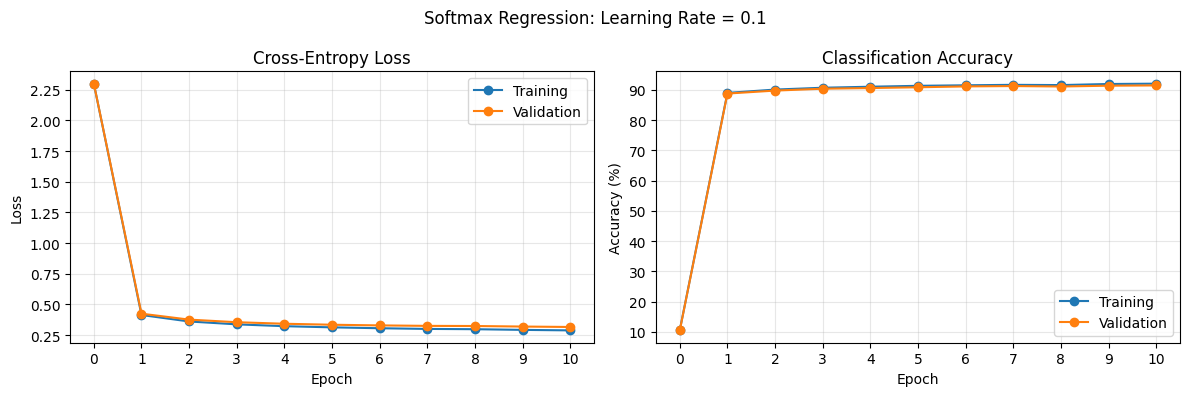

Figure saved: /content/A2_outputs/figures/01_baseline_learning_curves.png


In [ ]:
epochs = history_baseline["epoch"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cross-entropy loss.
axes[0].plot(
    epochs,
    history_baseline["train_loss"],
    marker="o",
    label="Training"
)
axes[0].plot(
    epochs,
    history_baseline["val_loss"],
    marker="o",
    label="Validation"
)
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Classification accuracy.
axes[1].plot(
    epochs,
    np.array(history_baseline["train_accuracy"]) * 100,
    marker="o",
    label="Training"
)
axes[1].plot(
    epochs,
    np.array(history_baseline["val_accuracy"]) * 100,
    marker="o",
    label="Validation"
)
axes[1].set_title("Classification Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(epochs)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"Softmax Regression: Learning Rate = {BASELINE_LR:g}")
fig.tight_layout()

# Save directly to the project's figure folder.
figure_path = figure_dir / "01_baseline_learning_curves.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

### 6.1 Baseline observations
After ten epochs, training accuracy is **92.04%** and validation accuracy is **91.46%**, a gap of 0.58 percentage points. Training and validation losses are 0.2877 and 0.3155 respectively. The curves show rapid initial improvement followed by slower gains; they do not establish full convergence.

Between epochs 7 and 8, validation loss decreases from 0.3245 to 0.3234, while validation accuracy falls from 91.25% to 91.10%. This is an observed example of the distinction between the training objective and decision accuracy. Individual probability changes were not stored for those epochs, so their precise contribution has not been analysed.

The learning curves are saved directly to the configured figure folder. The next cell saves the baseline model parameters, experiment settings and training history.

In [ ]:
# Save the baseline model.
model_file = output_dir / "baseline_model.npz"

np.savez_compressed(
    model_file,
    W=W_baseline,
    b=b_baseline
)

# Save experiment settings and training history.
experiment = {
    "settings": {
        "learning_rate": BASELINE_LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": int(SEED),
        "n_train": int(len(y_train))
    },
    "history": history_baseline
}

history_file = output_dir / "baseline_training.json"

with open(history_file, "w", encoding="utf-8") as file:
    json.dump(experiment, file, indent=2)

print("Baseline model saved to:", model_file.resolve())
print("Training history saved to:", history_file.resolve())

Baseline model saved to: /content/A2_outputs/baseline_model.npz
Training history saved to: /content/A2_outputs/baseline_training.json


## 7. Experiment 1: learning rate
**Question:** How does learning rate affect optimisation over a fixed ten-epoch budget?

Compare 0.01, 0.1 and 1.0 using the same 50,000 training images, validation set, initialisation, batch order and batch size. The completed 0.1 baseline is reused. Each model receives 3,910 updates. Selection compares final-epoch validation loss, not the best intermediate epoch. The plotted curves omit epoch 0 to make differences during training easier to see.

In [ ]:
# Reuse the completed baseline.
lr_results = {
    BASELINE_LR: {
        "W": W_baseline,
        "b": b_baseline,
        "history": history_baseline
    }
}

# Train the configured rates other than the reused baseline.
for lr in LEARNING_RATES:
    if lr == BASELINE_LR:
        continue
    print(f"\nTraining with learning rate = {lr}")

    W_lr, b_lr, history_lr = train_softmax(
        X_train, y_train,
        X_val, y_val,
        learning_rate=lr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED
    )

    lr_results[lr] = {
        "W": W_lr,
        "b": b_lr,
        "history": history_lr
    }

    # Save each experiment immediately after it finishes.
    tag = str(lr).replace(".", "p")

    np.savez_compressed(
        output_dir / f"model_lr_{tag}.npz",
        W=W_lr,
        b=b_lr
    )

    experiment = {
        "settings": {
            "learning_rate": lr,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed": int(SEED)
        },
        "history": history_lr
    }

    with open(
        output_dir / f"training_lr_{tag}.json",
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(experiment, file, indent=2)

    print(f"Saved learning-rate experiment: {lr}")


Training with learning rate = 0.01
Epoch 00/10 | Train loss: 2.2986 | Val loss: 2.2990 | Train acc: 10.57% | Val acc: 10.48%
Epoch 01/10 | Train loss: 0.8887 | Val loss: 0.8900 | Train acc: 83.20% | Val acc: 83.36%
Epoch 02/10 | Train loss: 0.6677 | Val loss: 0.6712 | Train acc: 85.52% | Val acc: 85.57%
Epoch 03/10 | Train loss: 0.5769 | Val loss: 0.5817 | Train acc: 86.52% | Val acc: 86.75%
Epoch 04/10 | Train loss: 0.5256 | Val loss: 0.5314 | Train acc: 87.11% | Val acc: 87.38%
Epoch 05/10 | Train loss: 0.4919 | Val loss: 0.4987 | Train acc: 87.68% | Val acc: 87.80%
Epoch 06/10 | Train loss: 0.4677 | Val loss: 0.4754 | Train acc: 88.08% | Val acc: 88.10%
Epoch 07/10 | Train loss: 0.4494 | Val loss: 0.4579 | Train acc: 88.37% | Val acc: 88.37%
Epoch 08/10 | Train loss: 0.4348 | Val loss: 0.4440 | Train acc: 88.63% | Val acc: 88.53%
Epoch 09/10 | Train loss: 0.4227 | Val loss: 0.4326 | Train acc: 88.87% | Val acc: 88.73%
Epoch 10/10 | Train loss: 0.4126 | Val loss: 0.4230 | Train acc:

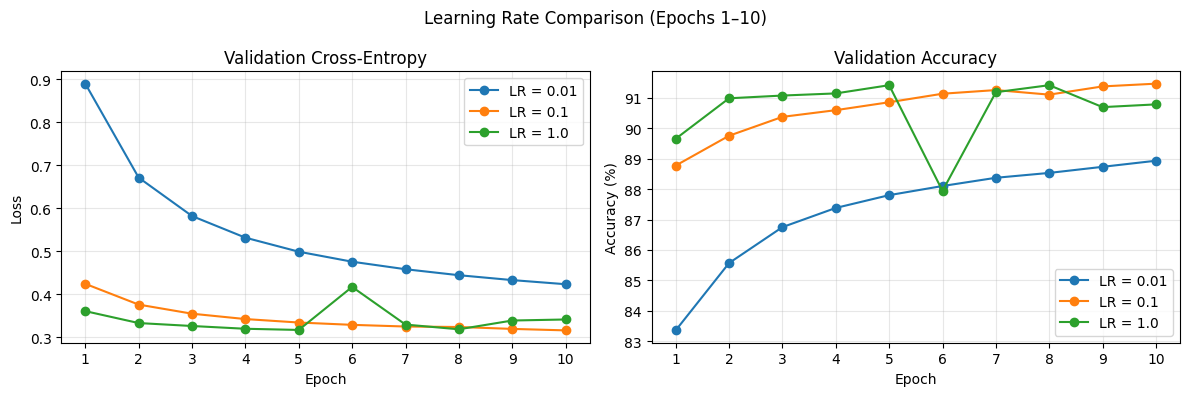

Figure saved: /content/A2_outputs/figures/02_learning_rate_comparison.png

Results after 10 epochs:
LR = 0.01 | Train loss: 0.4126 | Val loss: 0.4230 | Val accuracy: 88.93%
LR = 0.1  | Train loss: 0.2877 | Val loss: 0.3155 | Val accuracy: 91.46%
LR = 1.0  | Train loss: 0.2817 | Val loss: 0.3409 | Val accuracy: 90.78%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lr in sorted(lr_results):
    history = lr_results[lr]["history"]
    epochs_plot = history["epoch"][1:]

    axes[0].plot(
        epochs_plot,
        history["val_loss"][1:],
        marker="o",
        label=f"LR = {lr}"
    )

    axes[1].plot(
        epochs_plot,
        np.array(history["val_accuracy"][1:]) * 100,
        marker="o",
        label=f"LR = {lr}"
    )

axes[0].set_title("Validation Cross-Entropy")
axes[0].set_ylabel("Loss")

axes[1].set_title("Validation Accuracy")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(f"Learning Rate Comparison (Epochs 1–{EPOCHS})")
fig.tight_layout()

figure_path = figure_dir / "02_learning_rate_comparison.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

print(f"\nResults after {EPOCHS} epochs:")
for lr in sorted(lr_results):
    history = lr_results[lr]["history"]
    print(
        f"LR = {lr:<4} | "
        f"Train loss: {history['train_loss'][-1]:.4f} | "
        f"Val loss: {history['val_loss'][-1]:.4f} | "
        f"Val accuracy: {history['val_accuracy'][-1]:.2%}"
    )

### 7.1 Learning-rate findings
| Learning rate | Final training loss | Final validation loss | Final validation accuracy |
|---|---:|---:|---:|
| 0.01 | 0.4126 | 0.4230 | 88.93% |
| 0.1 | 0.2877 | 0.3155 | 91.46% |
| 1.0 | 0.2817 | 0.3409 | 90.78% |

The smallest rate improves steadily but is slower within this budget. Rate 1.0 improves quickly at first, then fluctuates: validation accuracy falls to 87.94% at epoch 6 before recovering. Simultaneous training-loss deterioration is consistent with optimisation instability from a large step, rather than sufficient evidence of overfitting alone.

Rate 0.1 has the lowest final validation loss and highest final validation accuracy among these runs. It is retained for subsequent work. This is a single-seed comparison, not a claim that 0.1 is universally optimal.

## 8. Experiment 2: training data size
Compare nested subsets containing the first 1,000, 10,000 and all 50,000 rows of the shuffled training set. Keep the validation set fixed, use learning rate 0.1 and train for ten epochs. Class counts are printed to document subset composition.

**Design limitation:** equal epochs do not mean equal optimisation budgets. The runs receive 80, 790 and 3,910 updates respectively. This experiment describes performance under a fixed-epoch protocol; it does not isolate the causal effect of data quantity.

In [ ]:
# Reuse the baseline trained on the full training split.
size_results = {
    len(y_train): {
        "W": W_baseline,
        "b": b_baseline,
        "history": history_baseline
    }
}

for n_samples in sorted(TRAINING_SUBSET_SIZES):
    X_subset = X_train[:n_samples]
    y_subset = y_train[:n_samples]

    print(f"\nTraining with {n_samples:,} images")
    print(
        "Class counts (digits 0–9):",
        np.bincount(y_subset, minlength=10)
    )

    W_size, b_size, history_size = train_softmax(
        X_subset, y_subset,
        X_val, y_val,
        learning_rate=BASELINE_LR,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED
    )

    size_results[n_samples] = {
        "W": W_size,
        "b": b_size,
        "history": history_size
    }

    # Save each completed model.
    np.savez_compressed(
        output_dir / f"model_size_{n_samples}.npz",
        W=W_size,
        b=b_size
    )

    experiment = {
        "settings": {
            "n_train": n_samples,
            "learning_rate": BASELINE_LR,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed": int(SEED),
            "subset_method": "First n rows of the shuffled training set",
            "total_updates": total_parameter_updates(n_samples)
        },
        "class_counts": np.bincount(
            y_subset, minlength=10
        ).tolist(),
        "history": history_size
    }

    with open(
        output_dir / f"training_size_{n_samples}.json",
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(experiment, file, indent=2)

    print(f"Saved experiment with {n_samples:,} training images.")


Training with 1,000 images
Class counts (digits 0–9): [101 117  97  92  99 108 104  92  94  96]
Epoch 00/10 | Train loss: 2.2994 | Val loss: 2.2990 | Train acc: 9.70% | Val acc: 10.48%
Epoch 01/10 | Train loss: 1.6360 | Val loss: 1.6658 | Train acc: 73.00% | Val acc: 71.58%
Epoch 02/10 | Train loss: 1.2750 | Val loss: 1.3186 | Train acc: 80.60% | Val acc: 78.89%
Epoch 03/10 | Train loss: 1.0671 | Val loss: 1.1161 | Train acc: 82.10% | Val acc: 79.91%
Epoch 04/10 | Train loss: 0.9321 | Val loss: 0.9902 | Train acc: 84.90% | Val acc: 80.74%
Epoch 05/10 | Train loss: 0.8402 | Val loss: 0.9034 | Train acc: 85.10% | Val acc: 81.05%
Epoch 06/10 | Train loss: 0.7686 | Val loss: 0.8359 | Train acc: 85.60% | Val acc: 82.58%
Epoch 07/10 | Train loss: 0.7200 | Val loss: 0.7895 | Train acc: 86.60% | Val acc: 82.21%
Epoch 08/10 | Train loss: 0.6739 | Val loss: 0.7492 | Train acc: 86.40% | Val acc: 83.30%
Epoch 09/10 | Train loss: 0.6403 | Val loss: 0.7219 | Train acc: 87.70% | Val acc: 83.16%
Epoc

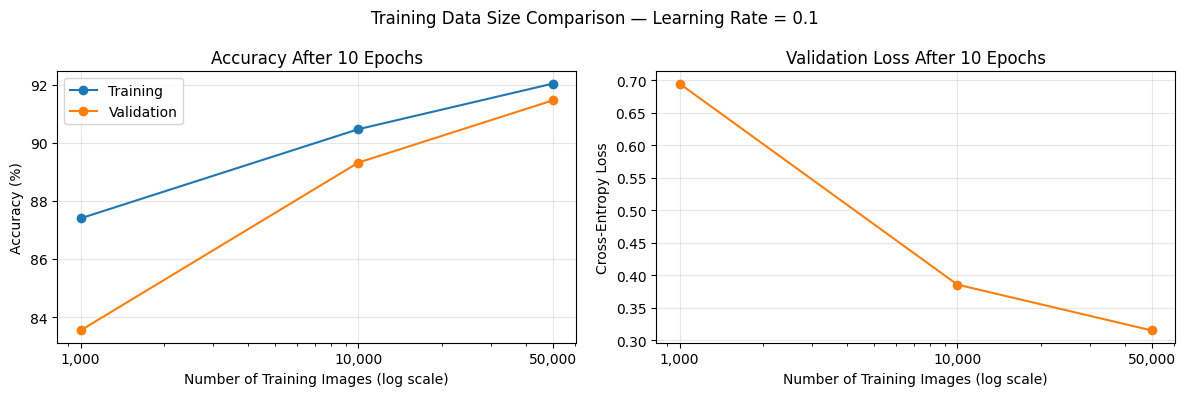

Figure saved: /content/A2_outputs/figures/03_training_data_size_comparison.png
N = 1,000 | Updates:   80 | Train acc: 87.40% | Val acc: 83.54% | Val loss: 0.6946
N = 10,000 | Updates:  790 | Train acc: 90.47% | Val acc: 89.32% | Val loss: 0.3858
N = 50,000 | Updates: 3910 | Train acc: 92.04% | Val acc: 91.46% | Val loss: 0.3155
Results saved to: /content/A2_outputs


In [ ]:
sizes = sorted(size_results)

train_acc = [
    size_results[n]["history"]["train_accuracy"][-1] * 100
    for n in sizes
]
val_acc = [
    size_results[n]["history"]["val_accuracy"][-1] * 100
    for n in sizes
]
val_loss = [
    size_results[n]["history"]["val_loss"][-1]
    for n in sizes
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sizes, train_acc, marker="o", label="Training")
axes[0].plot(sizes, val_acc, marker="o", label="Validation")
axes[0].set_title(f"Accuracy After {EPOCHS} Epochs")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

axes[1].plot(sizes, val_loss, marker="o", color="tab:orange")
axes[1].set_title(f"Validation Loss After {EPOCHS} Epochs")
axes[1].set_ylabel("Cross-Entropy Loss")

for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks(sizes)
    ax.set_xticklabels([f"{n:,}" for n in sizes])
    ax.set_xlabel("Number of Training Images (log scale)")
    ax.grid(alpha=0.3)

fig.suptitle(f"Training Data Size Comparison — Learning Rate = {BASELINE_LR:g}")
fig.tight_layout()

figure_path = figure_dir / "03_training_data_size_comparison.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

# Build and save the numeric summary.
rows = []

for n in sizes:
    h = size_results[n]["history"]
    row = {
        "n_train": n,
        "total_updates": total_parameter_updates(n),
        "train_loss": h["train_loss"][-1],
        "val_loss": h["val_loss"][-1],
        "train_accuracy": h["train_accuracy"][-1],
        "val_accuracy": h["val_accuracy"][-1]
    }
    rows.append(row)

    print(
        f"N = {n:>5,} | "
        f"Updates: {row['total_updates']:>4} | "
        f"Train acc: {row['train_accuracy']:.2%} | "
        f"Val acc: {row['val_accuracy']:.2%} | "
        f"Val loss: {row['val_loss']:.4f}"
    )

with open(
    output_dir / "training_data_size_summary.csv",
    "w",
    newline="",
    encoding="utf-8"
) as file:
    writer = csv.DictWriter(file, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)

print("Results saved to:", output_dir.resolve())

### 8.1 Data-size findings
| Training images | Updates | Training accuracy | Validation accuracy | Validation loss |
|---|---:|---:|---:|---:|
| 1,000 | 80 | 87.40% | 83.54% | 0.6946 |
| 10,000 | 790 | 90.47% | 89.32% | 0.3858 |
| 50,000 | 3,910 | 92.04% | 91.46% | 0.3155 |

Validation accuracy improves by 7.92 percentage points from the smallest to the largest run, and the training–validation accuracy gap decreases from 3.86 to 0.58 points. More data and more parameter updates both accompany the improvement. The small-data result cannot be attributed solely to overfitting; incomplete optimisation may also contribute.

## 9. Final model and held-out evaluation
The final model is selected automatically using the lowest
final-epoch validation loss among the tested learning rates.
The test set is not used for model selection.

In the recorded experiment, this selects the model trained on
50,000 images with a learning rate of 0.1 for ten epochs.
The selected parameters are copied without retraining on the
validation set.

The recorded test result is **92.04% accuracy** and
**0.2858 cross-entropy loss**, with 9,204 correct predictions
and 796 errors out of 10,000 images. Training and test accuracy
happen to round to the same value, but they are calculated
on separate datasets.

In [ ]:
# Select the model using final-epoch validation loss only.
best_lr = min(
    lr_results,
    key=lambda lr: lr_results[lr]["history"]["val_loss"][-1]
)

selected_result = lr_results[best_lr]
selected_history = selected_result["history"]

# Copy the selected parameters to keep the final model separate.
W_final = selected_result["W"].copy()
b_final = selected_result["b"].copy()

selected_epoch = int(selected_history["epoch"][-1])
selected_val_loss = float(selected_history["val_loss"][-1])
selected_val_accuracy = float(
    selected_history["val_accuracy"][-1]
)

print(f"Selected learning rate: {best_lr}")
print(f"Selected epoch:         {selected_epoch}")
print(f"Validation loss:        {selected_val_loss:.4f}")
print(f"Validation accuracy:    {selected_val_accuracy:.2%}")

# Evaluate the selected model on the held-out test set.
test_loss, test_accuracy = evaluate_model(
    X_test, y_test, W_final, b_final
)

test_predictions = predict(X_test, W_final, b_final)
correct_count = int(np.sum(test_predictions == y_test))
error_count = int(len(y_test) - correct_count)

print(f"\nTest images:   {len(y_test):,}")
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Correct:       {correct_count:,}")
print(f"Incorrect:     {error_count:,}")

# Save the final model.
model_file = output_dir / "final_model.npz"

np.savez_compressed(
    model_file,
    W=W_final,
    b=b_final
)

# Save the selection criteria, settings and test results.
test_results = {
    "selection_basis": (
        "Lowest final-epoch validation loss among the "
        "learning rates tested on the full training split. "
        "Test results are not used for model selection."
    ),
    "settings": {
        "n_train": int(len(y_train)),
        "learning_rate": float(best_lr),
        "epochs": selected_epoch,
        "batch_size": BATCH_SIZE,
        "seed": int(SEED)
    },
    "validation_loss": selected_val_loss,
    "validation_accuracy": selected_val_accuracy,
    "test_size": int(len(y_test)),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "correct_count": correct_count,
    "error_count": error_count
}

results_file = output_dir / "final_test_results.json"

with open(results_file, "w", encoding="utf-8") as file:
    json.dump(test_results, file, indent=2)

# Save predictions for the following error-analysis cells.
predictions_file = output_dir / "test_predictions.npz"

np.savez_compressed(
    predictions_file,
    y_true=y_test,
    y_pred=test_predictions
)

print("\nFinal model saved to:", model_file.resolve())
print("Test results saved to:", results_file.resolve())
print("Test predictions saved to:", predictions_file.resolve())

Selected learning rate: 0.1
Selected epoch:         10
Validation loss:        0.3155
Validation accuracy:    91.46%

Test images:   10,000
Test loss:     0.2858
Test accuracy: 92.04%
Correct:       9,204
Incorrect:     796

Final model saved to: /content/A2_outputs/final_model.npz
Test results saved to: /content/A2_outputs/final_test_results.json
Test predictions saved to: /content/A2_outputs/test_predictions.npz


### 9.1 Learned weight maps

Each panel reshapes one column of the final weight matrix into
a 28 × 28 image. All ten panels share the same colour scale.
Red indicates positive weights, blue indicates negative weights,
and white indicates weights close to zero.

For a fixed model, increasing a pixel value increases a class
score when its weight is positive and decreases that score when
its weight is negative. These effects refer to the class score
(logit), rather than directly to its Softmax probability.

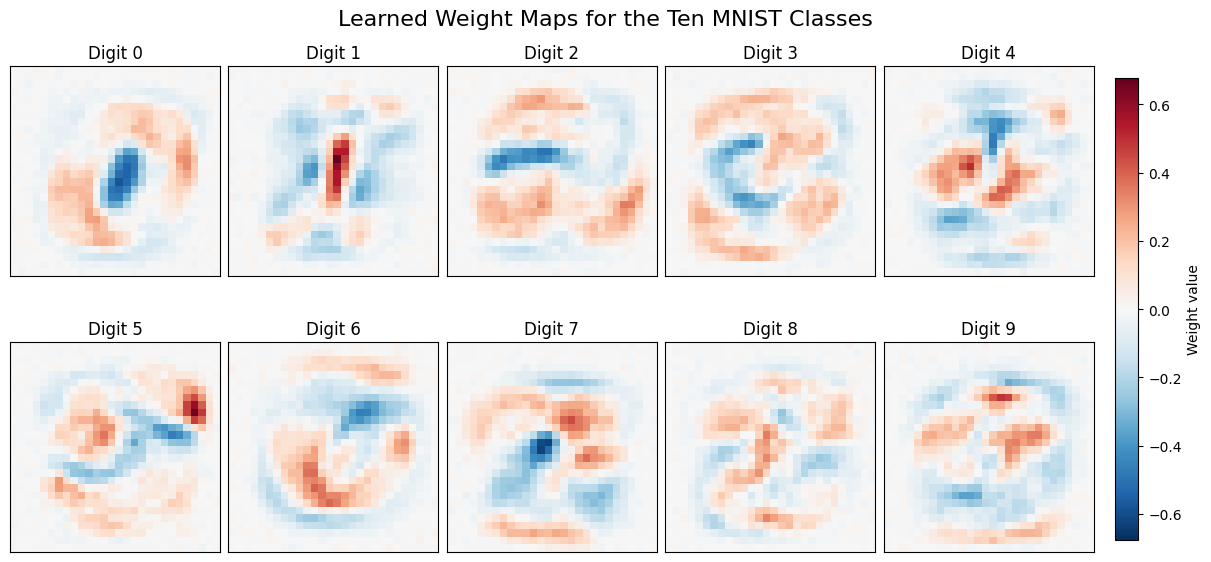

Figure saved: /content/A2_outputs/figures/07_weight_maps.png


In [ ]:
# Check dependencies before plotting.
required_variables = ["W_final", "figure_dir", "np", "plt", "TwoSlopeNorm"]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run the setup/import cells and Section 9 first. Missing: "
        + ", ".join(missing_variables)
    )
figure_dir.mkdir(parents=True, exist_ok=True)

weights = np.asarray(W_final)

if weights.shape != (784, 10):
    raise ValueError(
        f"Expected W_final shape (784, 10), received {weights.shape}."
    )

if not np.isfinite(weights).all():
    raise ValueError("Model weights contain non-finite values.")

# Use a shared, symmetric colour scale for all ten classes.
limit = float(np.max(np.abs(weights)))
if limit == 0:
    limit = 1.0

norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)

fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5.8),
    constrained_layout=True
)

for digit, ax in enumerate(axes.flat):
    weight_map = weights[:, digit].reshape(28, 28)

    heatmap = ax.imshow(
        weight_map,
        cmap="RdBu_r",
        norm=norm,
        interpolation="nearest"
    )

    ax.set_title(f"Digit {digit}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Learned Weight Maps for the Ten MNIST Classes",
    fontsize=16
)

colourbar = fig.colorbar(
    heatmap,
    ax=axes.ravel().tolist(),
    shrink=0.85,
    pad=0.02
)
colourbar.set_label("Weight value")

figure_path = figure_dir / "07_weight_maps.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

The weight map for digit 0 shows positive weights around parts
of the outer loop and negative weights near the centre. Digit 1
shows a strong positive vertical region near the centre.
These patterns are consistent with features that help distinguish
the corresponding digits.

The maps are learned coefficients, not average digit images or
attention maps. Predictions depend on all pixel contributions,
the biases and the competing class scores. This visualisation
helps interpret the model but does not establish the cause of
individual prediction errors.

## 10. Error analysis

These are descriptive analyses of the frozen model, not additional model-selection experiments.

### 10.1 Confusion matrix and per-class recall

The confusion matrix uses true labels as rows and predicted labels as columns. Its diagonal counts correct predictions. Per-class recall divides the diagonal count by the total number of true examples of that class, avoiding direct comparison of raw correct counts across unequal class sizes.

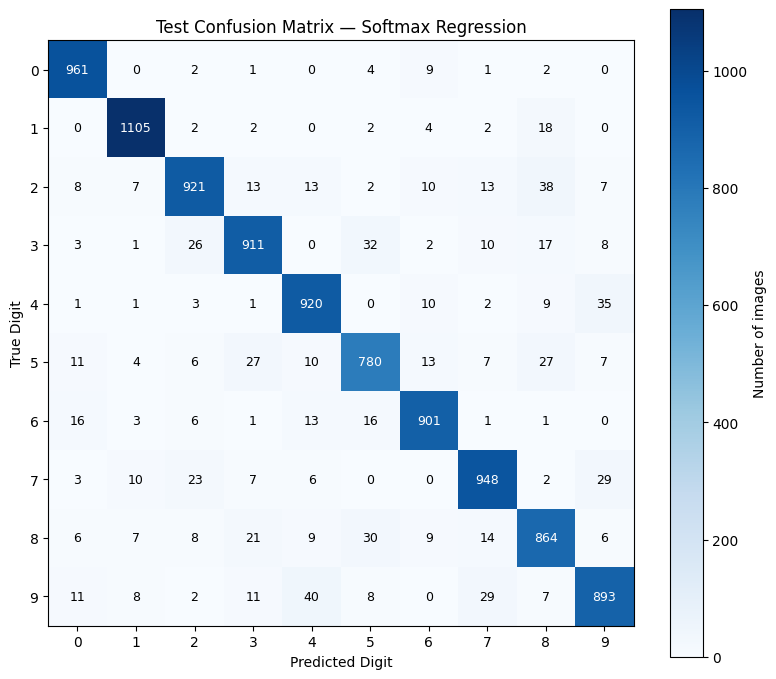

Figure saved: /content/A2_outputs/figures/04_test_confusion_matrix.png
Recall for each digit:
Digit 0: 98.06%
Digit 1: 97.36%
Digit 2: 89.24%
Digit 3: 90.20%
Digit 4: 93.69%
Digit 5: 87.44%
Digit 6: 94.05%
Digit 7: 92.22%
Digit 8: 88.71%
Digit 9: 88.50%

Most frequent mistakes:
True 9 -> Predicted 4: 40 images
True 2 -> Predicted 8: 38 images
True 4 -> Predicted 9: 35 images
True 3 -> Predicted 5: 32 images
True 8 -> Predicted 5: 30 images


In [ ]:
# Count predictions for each true/predicted class pair.
cm = np.zeros((10, 10), dtype=np.int64)
np.add.at(cm, (y_test, test_predictions), 1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, label="Number of images")

for i in range(10):
    for j in range(10):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=9
        )

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("Predicted Digit")
ax.set_ylabel("True Digit")
ax.set_title("Test Confusion Matrix — Softmax Regression")
fig.tight_layout()

figure_path = figure_dir / "04_test_confusion_matrix.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

np.savetxt(
    output_dir / "test_confusion_matrix.csv",
    cm,
    delimiter=",",
    fmt="%d",
    header="pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9",
    comments=""
)

# Recall: proportion of each true digit correctly recognised.
class_recall = np.diag(cm) / cm.sum(axis=1)

print("Recall for each digit:")
for digit, recall in enumerate(class_recall):
    print(f"Digit {digit}: {recall:.2%}")

# List the five most frequent directional mistakes.
mistakes = cm.copy()
np.fill_diagonal(mistakes, 0)

top_indices = np.argsort(
    -mistakes.ravel(), kind="stable"
)[:5]

print("\nMost frequent mistakes:")
for index in top_indices:
    true_digit, predicted_digit = np.unravel_index(
        index, mistakes.shape
    )
    print(
        f"True {true_digit} -> Predicted {predicted_digit}: "
        f"{mistakes[true_digit, predicted_digit]} images"
    )

### 10.2 Randomly selected error examples

The following plot uses a seeded random selection of twelve errors, rather than manually choosing examples that support an explanation. The saved indices allow the same images to be located again.

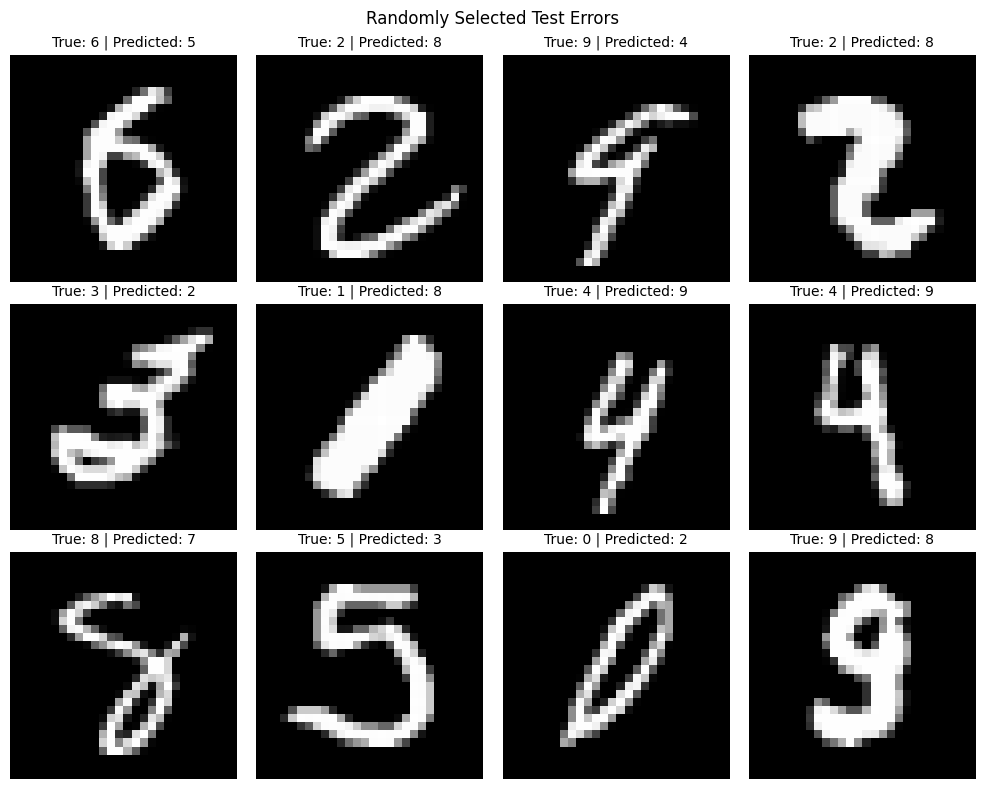

Figure saved: /content/A2_outputs/figures/05_test_error_examples.png
Results saved to: /content/A2_outputs


In [ ]:
error_indices = np.flatnonzero(test_predictions != y_test)

error_rng = np.random.default_rng(SEED)
selected_errors = error_rng.choice(
    error_indices,
    size=min(12, len(error_indices)),
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax in axes.flat:
    ax.axis("off")

for ax, index in zip(axes.flat, selected_errors):
    ax.imshow(
        X_test_raw[index],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    ax.set_title(
        f"True: {y_test[index]} | Predicted: {test_predictions[index]}",
        fontsize=10
    )

fig.suptitle("Randomly Selected Test Errors")
fig.tight_layout()

figure_path = figure_dir / "05_test_error_examples.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved: {figure_path.resolve()}")

# Save the selected examples' indices for reproducibility.
np.save(
    output_dir / "error_example_indices.npy",
    selected_errors
)

print("Results saved to:", output_dir.resolve())

### 10.3 Prediction confidence and errors

Confidence is defined here as the maximum Softmax probability.
The histogram compares correct and incorrect predictions on the
held-out MNIST test set. Each group is normalised separately,
so its bars sum to 100%; bar heights do not represent raw counts.

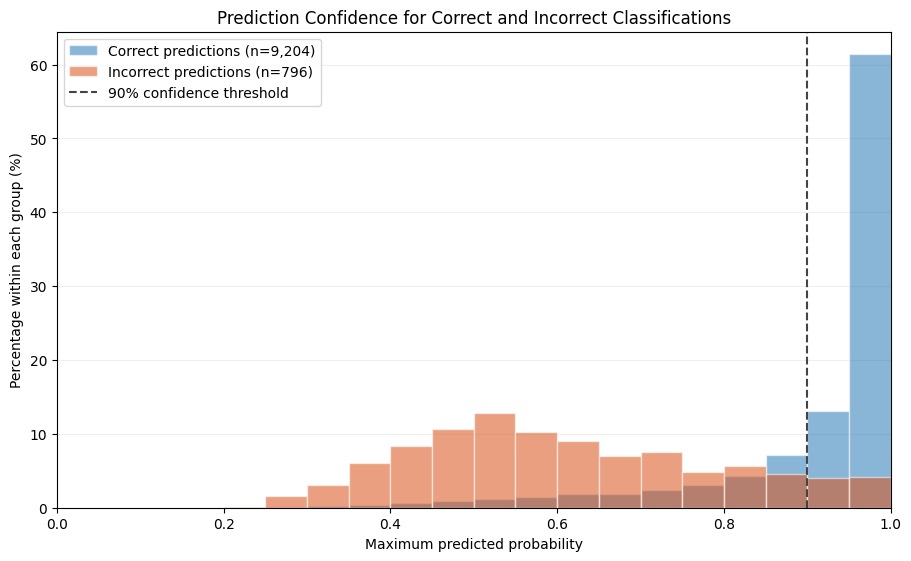

Test accuracy: 92.04%
Incorrect predictions: 796
Errors with confidence >= 90%: 65
Share of all errors with confidence >= 90%: 8.17%
Error rate among predictions with confidence >= 90%: 0.94%
Figure saved: /content/A2_outputs/figures/08_prediction_confidence.png
Prediction probabilities saved to: /content/A2_outputs/test_prediction_probabilities.npz
Confidence summary saved to: /content/A2_outputs/confidence_summary.json


In [ ]:
# Check that the final model and test data are available.
required_variables = [
    "W_final", "b_final", "X_test_raw", "y_test",
    "preprocess_images", "predict_proba", "output_dir",
    "figure_dir", "np", "plt", "json", "CONFIDENCE_THRESHOLD",
    "test_predictions"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the setup/import cells and the notebook through Section 9 first. Missing: "
        + ", ".join(missing_variables)
    )

figure_dir.mkdir(parents=True, exist_ok=True)

# Predict with the current final model.
confidence_X = preprocess_images(X_test_raw)
confidence_probabilities = np.asarray(
    predict_proba(confidence_X, W_final, b_final)
)
confidence_labels = np.asarray(y_test).reshape(-1)

if confidence_probabilities.shape != (len(confidence_labels), 10):
    raise ValueError("Expected one row of ten probabilities per test image.")

if (
    not np.isfinite(confidence_probabilities).all()
    or np.any(confidence_probabilities < 0)
    or np.any(confidence_probabilities > 1)
    or not np.allclose(
        confidence_probabilities.sum(axis=1), 1.0, atol=1e-6
    )
):
    raise ValueError("Invalid predicted probabilities.")

confidence_predictions = confidence_probabilities.argmax(axis=1)
confidence_values = confidence_probabilities.max(axis=1)
if not np.array_equal(confidence_predictions, test_predictions):
    raise RuntimeError("Predictions differ from Section 9. Rerun Section 9 and error analysis.")
correct_mask = confidence_predictions == confidence_labels

# Normalise each group separately.
bins = np.linspace(0.0, 1.0, 21)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

groups = [
    (correct_mask, "Correct predictions", "#2878B5"),
    (~correct_mask, "Incorrect predictions", "#D95319")
]

for mask, label, colour in groups:
    values = confidence_values[mask]

    if values.size:
        ax.hist(
            values,
            bins=bins,
            weights=np.full(values.size, 100.0 / values.size),
            alpha=0.55,
            color=colour,
            edgecolor="white",
            label=f"{label} (n={values.size:,})"
        )

ax.axvline(
    CONFIDENCE_THRESHOLD,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    label=f"{CONFIDENCE_THRESHOLD:.0%} confidence threshold"
)

ax.set(
    title="Prediction Confidence for Correct and Incorrect Classifications",
    xlabel="Maximum predicted probability",
    ylabel="Percentage within each group (%)",
    xlim=(0.0, 1.0)
)
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

figure_path = figure_dir / "08_prediction_confidence.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

# Summarise high-confidence errors with explicit denominators.
error_count = int((~correct_mask).sum())
high_confidence_mask = confidence_values >= CONFIDENCE_THRESHOLD
high_confidence_count = int(high_confidence_mask.sum())
high_confidence_errors = int(
    (high_confidence_mask & ~correct_mask).sum()
)

print(f"Test accuracy: {correct_mask.mean():.2%}")
print(f"Incorrect predictions: {error_count:,}")
print(f"Errors with confidence >= {CONFIDENCE_THRESHOLD:.0%}: {high_confidence_errors:,}")

if error_count:
    print(
        f"Share of all errors with confidence >= {CONFIDENCE_THRESHOLD:.0%}: "
        f"{high_confidence_errors / error_count:.2%}"
    )

if high_confidence_count:
    print(
        f"Error rate among predictions with confidence >= {CONFIDENCE_THRESHOLD:.0%}: "
        f"{high_confidence_errors / high_confidence_count:.2%}"
    )

print(f"Figure saved: {figure_path.resolve()}")

# Save per-image results in original test-set order.
probabilities_path = output_dir / "test_prediction_probabilities.npz"
np.savez_compressed(
    probabilities_path,
    test_index=np.arange(len(confidence_labels)),
    y_true=confidence_labels,
    y_pred=confidence_predictions,
    probabilities=confidence_probabilities,
    confidence=confidence_values
)

# Ratios are fractions in [0, 1]; null means the denominator is zero.
confidence_summary = {
    "confidence_definition": "Maximum Softmax probability",
    "confidence_threshold": float(CONFIDENCE_THRESHOLD),
    "test_size": int(len(confidence_labels)),
    "test_accuracy": float(correct_mask.mean()),
    "error_count": error_count,
    "high_confidence_count": high_confidence_count,
    "high_confidence_errors": high_confidence_errors,
    "share_of_errors_high_confidence": (
        high_confidence_errors / error_count if error_count else None
    ),
    "error_rate_among_high_confidence": (
        high_confidence_errors / high_confidence_count if high_confidence_count else None
    ),
    "ratio_units": "Fractions, not percentages; null when denominator is zero",
    "probabilities_file": probabilities_path.name
}
summary_path = output_dir / "confidence_summary.json"
with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(confidence_summary, file, indent=2, allow_nan=False)
print("Prediction probabilities saved to:", probabilities_path.resolve())
print("Confidence summary saved to:", summary_path.resolve())


Correct predictions are concentrated near high confidence,
particularly in the 0.95–1.00 interval. Incorrect predictions
have a broader distribution, with the largest bin around
0.50–0.55, but some errors also occur at high confidence.

Of the 796 incorrect predictions, 65 have confidence of at least
90%. These account for 8.17% of all errors. In contrast, the error
rate among all predictions with confidence of at least 90% is
0.94%. The two percentages use different denominators.

These results show that high-confidence predictions are generally
more reliable on this test set, but high confidence does not
guarantee correctness. This histogram alone does not establish
whether the model is well calibrated. The results apply to the
MNIST test set and should not be treated as measurements of
handwriting-canvas performance.

### 10.4 Observations and limitations
The most frequent directional errors are 9 → 4 (40 images), 2 → 8 (38), 4 → 9 (35), 3 → 5 (32), and 8 → 5 (30). The two directions between 4 and 9 total 75 errors. Digit 0 has the highest recall (98.06%), while digit 5 has the lowest (87.44%).

The example images show variation in stroke thickness, slant and shape. Some errors are visually ambiguous, but some digits remain recognisable to a human. These examples do not establish a unique cause for each error. The linear score function and absence of explicit local spatial features are plausible model limitations, not experimentally isolated explanations.

Further limitations include one split and random seed, no uncertainty estimates across repeated runs, only ten epochs, and the unequal-update data-size comparison. The test result estimates performance on the MNIST test distribution, not arbitrary handwriting photographs. Future work could compare matched update budgets, repeated seeds, nonlinear models and controlled image augmentation. None of those improvements has been tested here.

## 11. Conclusion
A NumPy implementation of Softmax regression achieved 92.04% held-out test accuracy. The implementation connects the hypothesis space, cross-entropy objective and gradient-based optimisation to explicit code. The experiments show a learning-rate trade-off within a fixed training budget and improved validation performance with larger training sets under a fixed-epoch protocol. Probability, loss and finite-difference checks provide concrete verification evidence. Remaining classification errors and experimental limitations motivate future work without changing the selected model after test evaluation.

## 12. Interactive demonstrations

Both interfaces use the final model selected in Section 9 and
share the same prediction function. No training occurs during
the demonstrations.

The dataset browser displays an MNIST test image, its predicted
class, its known label and the predicted class probabilities.

The handwriting canvas accepts a newly drawn digit. It crops
the drawing, resizes it while preserving its aspect ratio,
and centres it on a 28 × 28 grayscale image before prediction.

The reported 92.04% accuracy applies to the MNIST test set.
Accuracy on canvas drawings has not been measured systematically.
A high predicted probability does not guarantee a correct answer.

Run the preparation cell below before using either interface.

In [ ]:
# Check that the required experiment steps are complete.
required_variables = [
    "output_dir",
    "figure_dir",
    "W_final",
    "b_final",
    "X_test_raw",
    "y_test",
    "preprocess_images",
    "predict_proba"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Required variables are missing: "
        + ", ".join(missing_variables)
        + ". Run the notebook from the beginning through Section 9."
    )

# Load the final model from the configured output folder.
model_path = output_dir / "final_model.npz"

if not model_path.is_file():
    raise FileNotFoundError(
        f"Final model not found: {model_path.resolve()}. "
        "Run the code under Section 9 first."
    )

with np.load(model_path, allow_pickle=False) as saved_model:
    demo_W = saved_model["W"].copy()
    demo_b = saved_model["b"].copy()

# Check the parameter shapes and model consistency.
if demo_W.shape != (784, 10) or demo_b.shape != (10,):
    raise ValueError("Expected model shapes: W=(784, 10), b=(10,).")

if (
    not np.array_equal(demo_W, W_final)
    or not np.array_equal(demo_b, b_final)
):
    raise RuntimeError(
        "The saved model does not match the current final model. "
        "Rerun Section 9, then rerun this cell."
    )

# Reuse the test data for the dataset browser.
demo_images = X_test_raw
demo_labels = y_test

# Share one prediction function between both interfaces.
def demo_predict(image):
    image = np.asarray(image)

    if image.shape != (28, 28):
        raise ValueError(
            f"Expected a 28 x 28 image, received {image.shape}."
        )

    x = preprocess_images(image[None, ...])
    return predict_proba(x, demo_W, demo_b)[0]


print("Model loaded from:", model_path.resolve())
print("Verified: the demo uses the current final model.")
print("Figure folder:", figure_dir.resolve())
print("Ready: run the dataset browser and handwriting canvas below.")

Model loaded from: /content/A2_outputs/final_model.npz
Verified: the demo uses the current final model.
Figure folder: /content/A2_outputs/figures
Ready: run the dataset browser and handwriting canvas below.


In [ ]:
import io
import ipywidgets as widgets
from IPython.display import display

# Controls
image_selector = widgets.BoundedIntText(
    value=0,
    min=0,
    max=len(demo_images) - 1,
    description="Image index:",
    layout=widgets.Layout(width="220px")
)

previous_button = widgets.Button(description="Previous")
next_button = widgets.Button(description="Next")
save_button = widgets.Button(
    description="Save figure",
    button_style="success"
)

demo_output = widgets.Image(
    format="png",
    layout=widgets.Layout(width="900px", max_width="100%")
)
save_message = widgets.HTML()


def create_demo_figure(index):
    probabilities = demo_predict(demo_images[index])
    prediction = int(np.argmax(probabilities))
    true_label = int(demo_labels[index])
    status = "Correct" if prediction == true_label else "Incorrect"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(
        demo_images[index], cmap="gray", vmin=0, vmax=255
    )
    axes[0].set_title(f"Input Image — Index {index}")
    axes[0].axis("off")

    colors = [
        "tab:orange" if digit == prediction else "tab:blue"
        for digit in range(10)
    ]

    axes[1].bar(range(10), probabilities * 100, color=colors)
    axes[1].set_xticks(range(10))
    axes[1].set_ylim(0, 100)
    axes[1].set_xlabel("Digit")
    axes[1].set_ylabel("Predicted Probability (%)")
    axes[1].set_title("Model Output")

    fig.suptitle(
        f"Predicted: {prediction} | True: {true_label} | {status}",
        fontsize=14
    )
    fig.tight_layout()
    return fig


def refresh_demo(change=None):
    index = image_selector.value

    previous_button.disabled = (index == 0)
    next_button.disabled = (index == len(demo_images) - 1)
    save_message.value = ""

    # Render the figure without displaying additional output.
    with plt.ioff():
        fig = create_demo_figure(index)

    try:
        with io.BytesIO() as buffer:
            fig.savefig(
                buffer,
                format="png",
                dpi=110,
                bbox_inches="tight"
            )
            # Replace the existing image.
            demo_output.value = buffer.getvalue()
    finally:
        plt.close(fig)


def show_previous(button):
    image_selector.value = max(0, image_selector.value - 1)


def show_next(button):
    image_selector.value = min(
        len(demo_images) - 1,
        image_selector.value + 1
    )


def save_current_figure(button):
    index = image_selector.value
    fig = create_demo_figure(index)

    try:
        saved_path = (
            figure_dir / f"demo_image_{index:05d}.png"
        )
        fig.savefig(saved_path, dpi=300, bbox_inches="tight")
    finally:
        plt.close(fig)

    save_message.value = (
        f"<b>Figure saved:</b> {saved_path.resolve()}"
    )

image_selector.observe(refresh_demo, names="value")
previous_button.on_click(show_previous)
next_button.on_click(show_next)
save_button.on_click(save_current_figure)

display(
    widgets.VBox([
        widgets.HTML("<h3>Handwritten Digit Recognition</h3>"),
        widgets.HBox([
            previous_button,
            next_button,
            image_selector,
            save_button
        ]),
        save_message,
        demo_output
    ])
)

refresh_demo()

In [ ]:
import base64
import io
import uuid

from PIL import Image
from IPython.display import display, HTML, JSON
from google.colab import output

# Run the preparation cell in Section 12 first.
if "demo_predict" not in globals():
    raise RuntimeError("Run the preparation cell in Section 12 first.")


def recognise_handwriting(data_url):
    # Read the drawing as a grayscale image.
    image_bytes = base64.b64decode(data_url.split(",", 1)[1])
    image = Image.open(io.BytesIO(image_bytes)).convert("L")
    pixels = np.asarray(image)

    # Detect the written digit and reject an empty canvas.
    rows, cols = np.where(pixels > 20)
    if len(rows) < 20:
        return {"error": "Please draw one digit first."}

    # Crop empty space around the digit.
    digit = image.crop((
        int(cols.min()),
        int(rows.min()),
        int(cols.max()) + 1,
        int(rows.max()) + 1
    ))

    # Fit the digit inside a 20 x 20 box, preserving its shape.
    scale = 20.0 / max(digit.size)
    new_size = (
        max(1, round(digit.width * scale)),
        max(1, round(digit.height * scale))
    )
    digit = digit.resize(new_size, Image.Resampling.LANCZOS)

    # Place it on a black 28 x 28 background.
    processed = Image.new("L", (28, 28), 0)
    processed.paste(
        digit,
        ((28 - digit.width) // 2, (28 - digit.height) // 2)
    )

    # Centre the digit using its pixel-intensity centre of mass.
    array = np.asarray(processed, dtype=np.float32)
    yy, xx = np.indices(array.shape)
    mass = array.sum()
    centre_x = float((xx * array).sum() / mass)
    centre_y = float((yy * array).sum() / mass)
    shift_x = round(13.5 - centre_x)
    shift_y = round(13.5 - centre_y)

    centred = Image.new("L", (28, 28), 0)
    centred.paste(processed, (shift_x, shift_y))

    # demo_predict already performs flattening and normalization.
    model_input = np.asarray(centred, dtype=np.uint8)
    probabilities = np.asarray(
        demo_predict(model_input), dtype=float
    ).reshape(-1)

    if probabilities.size != 10 or not np.all(np.isfinite(probabilities)):
        raise ValueError("Expected ten finite class probabilities.")

    prediction = int(np.argmax(probabilities))

    # Return a preview of the actual model input.
    preview = io.BytesIO()
    centred.save(preview, format="PNG")
    preview_url = (
        "data:image/png;base64,"
        + base64.b64encode(preview.getvalue()).decode("ascii")
    )

    return {
        "prediction": prediction,
        "probabilities": probabilities.tolist(),
        "preview": preview_url
    }


# A unique callback allows this cell to be run more than once.
demo_id = "handwriting_" + uuid.uuid4().hex
callback_name = demo_id + ".predict"


def handwriting_callback(data_url):
    try:
        result = recognise_handwriting(data_url)
        return JSON(result)
    except Exception as error:
        return JSON({
            "error": f"{type(error).__name__}: {error}"
        })

output.register_callback(callback_name, handwriting_callback)

html = """
<div id="__ID__" style="font-family:Arial;max-width:850px;padding:16px;
border:1px solid #ddd;border-radius:12px">
  <h3>Draw a Digit — Softmax Regression</h3>
  <p>Draw one digit (0–9). Use a large, clear shape.</p>

  <div style="display:flex;gap:28px;flex-wrap:wrap">
    <div>
      <canvas width="280" height="280"
        style="background:black;border:1px solid #888;
        touch-action:none;cursor:crosshair"></canvas>
      <div style="margin-top:12px">
        <button class="clear" style="padding:9px 20px">Clear</button>
        <button class="recognise"
          style="padding:9px 20px;background:#1976d2;
          color:white;border:0;border-radius:4px">Recognise</button>
      </div>
    </div>

    <div style="min-width:260px;flex:1">
      <div class="status" style="font-size:20px;margin-bottom:12px">
        Waiting for input
      </div>
      <div class="result" hidden>
        <div style="display:flex;align-items:center;gap:12px">
          <img class="preview" width="84" height="84"
            style="image-rendering:pixelated;background:black">
          <span>Model input<br>28 × 28 pixels</span>
        </div>
        <div class="bars" style="margin-top:12px"></div>
        <p style="font-size:12px;color:#555">
          Model probability does not guarantee a correct prediction.
        </p>
      </div>
    </div>
  </div>
</div>

<script>
(() => {
  const root = document.getElementById("__ID__");
  const canvas = root.querySelector("canvas");
  const ctx = canvas.getContext("2d");
  const status = root.querySelector(".status");
  const result = root.querySelector(".result");
  const recognise = root.querySelector(".recognise");
  const clear = root.querySelector(".clear");
  let drawing = false;
  let busy = false;

  function resetCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
    ctx.strokeStyle = "white";
    ctx.lineWidth = 18;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";
    result.hidden = true;
    status.textContent = "Waiting for input";
  }

  function point(event) {
    const rect = canvas.getBoundingClientRect();
    return [
      (event.clientX - rect.left) * canvas.width / rect.width,
      (event.clientY - rect.top) * canvas.height / rect.height
    ];
  }

  canvas.addEventListener("pointerdown", event => {
    if (busy) return;
    event.preventDefault();
    drawing = true;
    canvas.setPointerCapture(event.pointerId);
    const [x, y] = point(event);
    ctx.beginPath();
    ctx.moveTo(x, y);
    ctx.lineTo(x + 0.1, y + 0.1);
    ctx.stroke();
    result.hidden = true;
    status.textContent = "Click Recognise when ready";
  });

  canvas.addEventListener("pointermove", event => {
    if (!drawing || busy) return;
    event.preventDefault();
    const [x, y] = point(event);
    ctx.lineTo(x, y);
    ctx.stroke();
  });

  function stopDrawing() { drawing = false; }
  canvas.addEventListener("pointerup", stopDrawing);
  canvas.addEventListener("pointercancel", stopDrawing);
  canvas.addEventListener("lostpointercapture", stopDrawing);

  clear.addEventListener("click", resetCanvas);

  recognise.addEventListener("click", async () => {
    busy = true;
    drawing = false;
    recognise.disabled = true;
    clear.disabled = true;
    result.hidden = true;
    status.textContent = "Recognising...";

    try {
      const response = await google.colab.kernel.invokeFunction(
        "__CALLBACK__", [canvas.toDataURL("image/png")], {}
      );
      const data = response.data["application/json"];

      if (data.error) {
        status.textContent = data.error;
        return;
      }

      status.textContent = "Predicted digit: " + data.prediction;
      root.querySelector(".preview").src = data.preview;
      const bars = root.querySelector(".bars");
      bars.replaceChildren();

      data.probabilities.forEach((probability, digit) => {
        const row = document.createElement("div");
        row.style.cssText =
          "display:flex;align-items:center;gap:8px;margin:5px 0";

        const label = document.createElement("span");
        label.textContent = digit;
        label.style.width = "14px";

        const track = document.createElement("div");
        track.style.cssText =
          "width:170px;height:12px;background:#eee";

        const bar = document.createElement("div");
        bar.style.width = (100 * probability) + "%";
        bar.style.height = "100%";
        bar.style.background =
          digit === data.prediction ? "#ff9800" : "#1976d2";
        track.appendChild(bar);

        const value = document.createElement("span");
        value.textContent = (100 * probability).toFixed(1) + "%";
        value.style.fontSize = "12px";

        row.append(label, track, value);
        bars.appendChild(row);
      });

      result.hidden = false;
    } catch (error) {
      status.textContent =
        "Prediction failed. Check the runtime and model-loading cell.";
      console.error(error);
    } finally {
      busy = false;
      recognise.disabled = false;
      clear.disabled = false;
    }
  });

  resetCanvas();
})();
</script>
"""

display(HTML(
    html.replace("__ID__", demo_id)
        .replace("__CALLBACK__", callback_name)
))

## 13. Implementation log and AI-use disclosure

### 13.1 Implementation log

The following log summarises the main implementation stages and subsequent refinements. It is a retrospective summary, rather than a timestamped record of every development action.

| Stage | Implementation and refinement |
|---|---|
| Data preparation | Loaded MNIST, created separate training and validation subsets, and retained the official test set for final evaluation. Flattened the images and scaled pixel values to [0, 1]. |
| Model implementation | Implemented linear scores, numerically stable Softmax, cross-entropy loss and analytical gradients explicitly in NumPy. |
| Implementation checks | Included probability-distribution checks, a uniform-prediction loss check, a one-step update check and a finite-difference gradient check. |
| Training and experiments | Implemented mini-batch gradient descent and compared learning rates and training subset sizes. Recorded training and validation metrics, and documented the unequal update counts in the fixed-epoch data-size experiment. |
| Final evaluation | Selected the final model using final-epoch validation loss, then evaluated it on the held-out test set. Saved model parameters, evaluation results and predictions. |
| Interpretation and error analysis | Added learned weight maps and prediction-confidence distributions alongside the confusion matrix and sampled errors. Distinguished high-confidence errors as a share of all errors from the error rate among high-confidence predictions. |
| Interactive demonstrations | Included an MNIST image browser and a handwriting canvas. Added a check that the model loaded for the demonstrations matches the current final model. |
| Organisation and reproducibility | Numbered the analysis subsections, placed interpretations after their figures, centralised experiment settings and added saved confidence-analysis data. Expanded checks for configuration, data validity, split overlap and plotting dependencies. |

After these refinements, I reran the complete notebook in Google Colab and confirmed that it completed successfully. This verifies execution in that environment; it does not establish performance across multiple random seeds or accuracy on unrestricted handwritten inputs.

### 13.2 AI-use disclosure

AI tools (such as ChatGPT/Codex) were used in this project for two purposes: initial topic ideation and English grammar polishing for the written text.

All Python code, including model implementation, gradient computations, and experimental checks, was written by me. I ran the complete notebook in Google Colab and confirmed successful execution. All experimental results are produced by my own code. I remain fully responsible for the accuracy of the analysis and the final submission.